# Skenario 02 — Optimasi PSO untuk Random Forest dan SVR pada Data Gabungan

Notebook ini memakai data gabungan, pseudo-RUL, fitur, pembagian acak, dan ruang pencarian yang sama dengan notebook ABC Skenario 02. PT Amanah memakai Break aktual, sedangkan tiga unit lain memakai estimasi dari model terbaik Skenario 01. Perbedaannya hanya metode optimasi: posisi, kecepatan, personal best, dan global best mengikuti Particle Swarm Optimization (PSO).

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score, recall_score
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
np.random.seed(SEED)

## Konfigurasi dan persiapan data

In [2]:
SENSOR_COLS = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]
LIFE_COL = "Unit Lifetime (Hour)"
STATUS_COL = "Status"
TARGET_COL = "sisa jam"
UNIT_COL = "unit_id"
TARGET_SOURCE_COL = "target_source"
BREAK_COL = "estimated_break_hour"
FEATURE_COLS = SENSOR_COLS.copy()
COLUMN_ALIASES = {f"{col} (°C)": col for col in SENSOR_COLS[:4]}

cfg = {
    "data_file": "datas/vehicle-health-gabungan.xlsx",
    "reference_model": "newcode/scenarios/01_RF_SVR_data_single/models/best_model.joblib",
    "max_rul": 2550.0,
    "test_size": 0.20,
    "cv_folds": 5,
    "swarm_size": 20,
    "iterations": 30,
    "patience": 8,
    "thresholds": [100, 250, 500],
    "primary_threshold": 250,
    "inertia": 0.7,
    "cognitive": 1.5,
    "social": 1.5,
}
SOURCE_FILES = {
    "unit_231": "datas/Data_Maluku_Utara_Unit_231_STATUS_FINAL.xlsx",
    "pt_amanah": "datas/Data_PT.Amanah_Critical_Break.xlsx",
    "unit_230": "datas/Data_Maluku_Utara_Unit_230_STATUS_FINAL.xlsx",
    "unit_228": "datas/Data_Maluku_Utara_Unit_228_STATUS_FINAL.xlsx",
}
RF_KEYS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
RF_BOUNDS = np.array([[50, 300], [2, 30], [2, 20], [1, 10], [0.1, 1.0]], dtype=float)
SVR_KEYS = ["C", "epsilon", "gamma"]
SVR_BOUNDS = np.array([[0.1, 1000], [0.001, 50], [0.0001, 1]], dtype=float)

def find_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / cfg["data_file"]).exists():
            return path
    raise FileNotFoundError(f"Dataset tidak ditemukan: {cfg['data_file']}")

def clean_data(raw):
    data = raw.rename(columns=COLUMN_ALIASES)[[*FEATURE_COLS, LIFE_COL, STATUS_COL]].copy()
    for col in FEATURE_COLS:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data[LIFE_COL] = pd.to_numeric(data[LIFE_COL], errors="coerce")
    data[STATUS_COL] = data[STATUS_COL].astype("string").str.strip().str.casefold()
    return data.dropna(subset=[*FEATURE_COLS, LIFE_COL, STATUS_COL]).reset_index(drop=True)

def prepare_data(root):
    data = clean_data(pd.read_excel(root / cfg["data_file"]))
    data["_row_order"] = np.arange(len(data))
    source_parts = []
    for unit_id, file_name in SOURCE_FILES.items():
        part = clean_data(pd.read_excel(root / file_name))
        part[UNIT_COL] = unit_id
        source_parts.append(part)
    source = pd.concat(source_parts, ignore_index=True)
    match_cols = [*FEATURE_COLS, LIFE_COL, STATUS_COL]
    if source.duplicated(match_cols).any():
        raise ValueError("Baris sumber tidak unik; identitas unit tidak dapat direkonstruksi dengan aman")
    data = data.merge(source[match_cols + [UNIT_COL]], on=match_cols, how="left", validate="one_to_one", sort=False)
    if data[UNIT_COL].isna().any() or len(data) != len(source):
        raise ValueError("Tidak seluruh baris data gabungan berhasil dipetakan ke unit sumber")
    data = data.sort_values("_row_order").drop(columns="_row_order").reset_index(drop=True)
    reference_path = root / cfg["reference_model"]
    if not reference_path.exists():
        raise FileNotFoundError(f"Model referensi tidak ditemukan: {reference_path}. Jalankan Build Models Skenario 01.")
    reference_model = joblib.load(reference_path)
    break_hours = {}
    target_sources = {}
    for unit_id, group in data.groupby(UNIT_COL, sort=False):
        actual_break = group.loc[group[STATUS_COL].eq("break"), LIFE_COL].max()
        if pd.notna(actual_break):
            break_hours[unit_id] = float(actual_break)
            target_sources[unit_id] = "actual"
        else:
            last = group.sort_values(LIFE_COL).iloc[-1]
            predicted_rul = float(np.clip(reference_model.predict(last[FEATURE_COLS].to_frame().T)[0], 0, cfg["max_rul"]))
            break_hours[unit_id] = float(last[LIFE_COL] + predicted_rul)
            target_sources[unit_id] = "estimated"
    data[BREAK_COL] = data[UNIT_COL].map(break_hours)
    data[TARGET_SOURCE_COL] = data[UNIT_COL].map(target_sources)
    data[TARGET_COL] = (data[BREAK_COL] - data[LIFE_COL]).clip(lower=0, upper=cfg["max_rul"])
    if data.empty:
        raise ValueError("Data valid tidak ditemukan")
    return data, break_hours

root = find_root()
out_dir = Path.cwd() / "artifacts" if Path.cwd().name == "02_RF_SVR_data_gabungan_pseudo_RUL" else root / "newcode/scenarios/02_RF_SVR_data_gabungan_pseudo_RUL/artifacts"
out_dir.mkdir(parents=True, exist_ok=True)
data, break_hours = prepare_data(root)
train_df, test_df = train_test_split(data, test_size=cfg["test_size"], shuffle=True, random_state=SEED)
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]
cv = KFold(n_splits=cfg["cv_folds"], shuffle=True, random_state=SEED)
print({"baris_data": len(data), "distribusi_unit": data[UNIT_COL].value_counts().to_dict(), "sumber_target": data[TARGET_SOURCE_COL].value_counts().to_dict(), "jam_break": break_hours, "fitur": FEATURE_COLS})

{'baris_data': 3168, 'distribusi_unit': {'pt_amanah': 2568, 'unit_231': 200, 'unit_230': 200, 'unit_228': 200}, 'sumber_target': {'actual': 2568, 'estimated': 600}, 'jam_break': {'unit_231': 54306.25769279888, 'pt_amanah': 78637.0, 'unit_230': 55006.6426331452, 'unit_228': 55628.49338681787}, 'fitur': ['Exhaust Gas Temperature LF (Left Front)', 'Exhaust Gas Temperature LR (Left Rear)', 'Exhaust Gas Temperature RF (Right Front)', 'Exhaust Gas Temperature RR (Right Rear)', 'Blowby Pressure (Kpa)', 'Boost Pressure (Kpa)', 'Engine Oil Temp (°C)', 'Coolant Temp (°C)']}


## Model, fungsi objektif, dan Particle Swarm Optimization

In [3]:
def decode_rf(pos):
    return {
        "n_estimators": int(round(pos[0])),
        "max_depth": int(round(pos[1])),
        "min_samples_split": int(round(pos[2])),
        "min_samples_leaf": int(round(pos[3])),
        "max_features": float(pos[4]),
    }

def decode_svr(pos):
    return {"C": float(pos[0]), "epsilon": float(pos[1]), "gamma": float(pos[2]), "kernel": "rbf"}

def make_model(kind, params):
    if kind == "rf":
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    return Pipeline([("scale", StandardScaler()), ("svr", SVR(**params))])

def make_objective(kind):
    decode = decode_rf if kind == "rf" else decode_svr
    cache = {}
    def objective(pos):
        params = decode(pos)
        key = tuple(round(val, 8) if isinstance(val, float) else val for val in params.values())
        if key not in cache:
            model = make_model(kind, params)
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)
            cache[key] = float(-scores.mean())
        return cache[key]
    objective.cache = cache
    return objective

def run_pso(objective, bounds, swarm_size=20, iterations=30, patience=8, inertia=0.7, cognitive=1.5, social=1.5, seed=42, label="Model"):
    started = time.perf_counter()
    rng = np.random.default_rng(seed)
    low, high = bounds[:, 0], bounds[:, 1]
    span = high - low
    pos = rng.uniform(low, high, size=(swarm_size, len(bounds)))
    vel = rng.uniform(-0.1 * span, 0.1 * span, size=pos.shape)
    fit = np.array([objective(item) for item in pos])
    pbest_pos, pbest_fit = pos.copy(), fit.copy()
    best_idx = int(np.argmin(pbest_fit))
    gbest_pos, gbest_fit = pbest_pos[best_idx].copy(), float(pbest_fit[best_idx])
    history = [gbest_fit]
    stale = 0
    print(f"[{label}] Inisialisasi selesai | MSE CV terbaik: {gbest_fit:.6f}", flush=True)
    for iteration in range(1, iterations + 1):
        r1 = rng.random(pos.shape)
        r2 = rng.random(pos.shape)
        vel = inertia * vel + cognitive * r1 * (pbest_pos - pos) + social * r2 * (gbest_pos - pos)
        vel = np.clip(vel, -span, span)
        pos = np.clip(pos + vel, low, high)
        fit = np.array([objective(item) for item in pos])
        improved = fit < pbest_fit
        pbest_pos[improved] = pos[improved]
        pbest_fit[improved] = fit[improved]
        best_idx = int(np.argmin(pbest_fit))
        if pbest_fit[best_idx] < gbest_fit:
            gbest_pos, gbest_fit = pbest_pos[best_idx].copy(), float(pbest_fit[best_idx])
            stale = 0
        else:
            stale += 1
        history.append(gbest_fit)
        elapsed = time.perf_counter() - started
        print(f"[{label}] Iterasi {iteration}/{iterations} | MSE CV terbaik: {gbest_fit:.6f} | Waktu: {elapsed:.1f} detik", flush=True)
        if patience > 0 and stale >= patience:
            print(f"[{label}] Berhenti dini: {stale} iterasi tanpa perbaikan.", flush=True)
            break
    return gbest_pos, gbest_fit, history, len(objective.cache)

## Jalankan optimasi dan evaluasi

Cell berikut menjalankan optimasi penuh untuk dua model. Waktu proses bergantung pada perangkat.

In [4]:
def metric_values(actual, pred):
    mse = float(mean_squared_error(actual, pred))
    r2 = float(r2_score(actual, pred)) if len(actual) >= 2 else None
    return {"mse": mse, "rmse": float(np.sqrt(mse)), "mae": float(mean_absolute_error(actual, pred)), "r2": r2}

def make_threshold_rows(actual, pred, scope):
    rows = []
    for threshold in cfg["thresholds"]:
        actual_alert = np.asarray(actual) <= threshold
        predicted_alert = np.asarray(pred) <= threshold
        tn, fp, fn, tp = confusion_matrix(actual_alert, predicted_alert, labels=[False, True]).ravel()
        rows.append({
            "scope": scope, "threshold": int(threshold),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "accuracy": float(accuracy_score(actual_alert, predicted_alert)),
            "precision": float(precision_score(actual_alert, predicted_alert, zero_division=0)),
            "recall": float(recall_score(actual_alert, predicted_alert, zero_division=0)),
            "f1": float(f1_score(actual_alert, predicted_alert, zero_division=0)),
        })
    return rows

def evaluate(kind, params, cv_mse, history, elapsed, evals):
    model = make_model(kind, params)
    oof_pred = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=1, method="predict")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    cv_metrics = metric_values(y_train, oof_pred)
    test_metrics = metric_values(y_test, pred)
    threshold_rows = [*make_threshold_rows(y_train, oof_pred, "cv_oof"), *make_threshold_rows(y_test, pred, "test")]
    for source in ["actual", "estimated"]:
        train_mask = train_df[TARGET_SOURCE_COL].eq(source)
        test_mask = test_df[TARGET_SOURCE_COL].eq(source)
        if train_mask.any():
            threshold_rows.extend(make_threshold_rows(y_train.loc[train_mask], oof_pred[train_mask.to_numpy()], f"cv_oof_{source}"))
        if test_mask.any():
            threshold_rows.extend(make_threshold_rows(y_test.loc[test_mask], pred[test_mask.to_numpy()], f"test_{source}"))
    meta_cols = [UNIT_COL, TARGET_SOURCE_COL, BREAK_COL, LIFE_COL, STATUS_COL, TARGET_COL]
    cv_pred_df = train_df[meta_cols].copy().rename(columns={TARGET_COL: "target_sisa_jam"})
    cv_pred_df["predicted_sisa_jam"] = oof_pred
    pred_df = test_df[meta_cols].copy().rename(columns={TARGET_COL: "target_sisa_jam"})
    pred_df["predicted_sisa_jam"] = pred
    def grouped_metrics(frame, column):
        return {str(key): {"rows": int(len(group)), **metric_values(group["target_sisa_jam"], group["predicted_sisa_jam"])} for key, group in frame.groupby(column)}
    metrics = {
        "optimizer": "PSO", "model": "Random Forest" if kind == "rf" else "SVR",
        "data_scope": "combined_pseudo_rul", "feature_scope": "sensor_only",
        "target": TARGET_COL, "features": FEATURE_COLS, "break_hours": break_hours,
        "reference_model": cfg["reference_model"],
        "best_params": params, "cv_mse": float(cv_mse), "cv_rmse": float(np.sqrt(cv_mse)),
        "test_mse": test_metrics["mse"], "test_rmse": test_metrics["rmse"], "test_mae": test_metrics["mae"], "test_r2": test_metrics["r2"],
        "cv_oof_metrics": cv_metrics, "test_metrics": test_metrics, "threshold_metrics": threshold_rows,
        "status_counts": {str(key): int(val) for key, val in data[STATUS_COL].value_counts().items()},
        "unit_counts": {str(key): int(val) for key, val in data[UNIT_COL].value_counts().items()},
        "target_source_counts": {str(key): int(val) for key, val in data[TARGET_SOURCE_COL].value_counts().items()},
        "test_metrics_by_status": grouped_metrics(pred_df, STATUS_COL),
        "test_metrics_by_unit": grouped_metrics(pred_df, UNIT_COL),
        "test_metrics_by_target_source": grouped_metrics(pred_df, TARGET_SOURCE_COL),
        "elapsed_seconds": float(elapsed),
        "objective_evaluations": int(evals), "seed": SEED,
    }
    model_dir = out_dir / f"pso_{kind}"
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_dir / "model.joblib")
    (model_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    cv_pred_df.to_csv(model_dir / "cv_predictions.csv", index=False)
    pred_df.to_csv(model_dir / "test_predictions.csv", index=False)
    pd.DataFrame(threshold_rows).to_csv(model_dir / "threshold_metrics.csv", index=False)
    actual_color, pred_color = "tab:green", "tab:purple"
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history, color=pred_color, label="MSE CV terbaik")
    axes[0].set(title=f"Konvergensi PSO {metrics['model']}", xlabel="Iterasi", ylabel="MSE CV terbaik")
    axes[0].legend()
    axes[1].scatter(y_test, pred, color=pred_color, alpha=0.65, label="Prediksi")
    edge = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[1].plot(edge, edge, color=actual_color, linewidth=2, label="Aktual ideal")
    axes[1].set(title=f"Aktual vs Prediksi {metrics['model']}", xlabel="Aktual sisa jam", ylabel="Prediksi sisa jam")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(model_dir / "evaluation.png", dpi=160, bbox_inches="tight")
    plt.show()
    primary = next(row for row in threshold_rows if row["scope"] == "cv_oof" and row["threshold"] == cfg["primary_threshold"])
    matrix = np.array([[primary["tn"], primary["fp"]], [primary["fn"], primary["tp"]]])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(y_train, oof_pred, color=pred_color, alpha=0.45, label="Prediksi OOF")
    edge = [min(y_train.min(), oof_pred.min()), max(y_train.max(), oof_pred.max())]
    axes[0].plot(edge, edge, color=actual_color, linewidth=2, label="Aktual ideal")
    axes[0].set(title=f"CV aktual vs prediksi {metrics['model']}", xlabel="Aktual sisa jam", ylabel="Prediksi OOF sisa jam")
    axes[0].legend()
    image = axes[1].imshow(matrix, cmap="Purples")
    for row in range(2):
        for col in range(2):
            labels = [["TN", "FP"], ["FN", "TP"]]
            axes[1].text(col, row, f"{labels[row][col]}\n{matrix[row, col]}", ha="center", va="center", color="black")
    axes[1].set(title=f"Confusion matrix CV ≤ {cfg['primary_threshold']} jam", xlabel="Prediksi", ylabel="Aktual", xticks=[0, 1], yticks=[0, 1], xticklabels=["Negatif", "Positif"], yticklabels=["Negatif", "Positif"])
    fig.colorbar(image, ax=axes[1], fraction=0.046)
    fig.tight_layout()
    fig.savefig(model_dir / "cv_validation.png", dpi=160, bbox_inches="tight")
    plt.show()
    return metrics

## Optimasi Random Forest

=== Mulai optimasi PSO Random Forest ===
[Random Forest] Inisialisasi selesai | MSE CV terbaik: 32321.069440
[Random Forest] Iterasi 1/30 | MSE CV terbaik: 29844.692985 | Waktu: 40.8 detik
[Random Forest] Iterasi 2/30 | MSE CV terbaik: 28211.904045 | Waktu: 66.1 detik
[Random Forest] Iterasi 3/30 | MSE CV terbaik: 28195.497791 | Waktu: 90.6 detik
[Random Forest] Iterasi 4/30 | MSE CV terbaik: 28195.497791 | Waktu: 111.6 detik
[Random Forest] Iterasi 5/30 | MSE CV terbaik: 28025.297522 | Waktu: 129.6 detik
[Random Forest] Iterasi 6/30 | MSE CV terbaik: 27909.463112 | Waktu: 153.0 detik
[Random Forest] Iterasi 7/30 | MSE CV terbaik: 27909.463112 | Waktu: 183.1 detik
[Random Forest] Iterasi 8/30 | MSE CV terbaik: 27906.126784 | Waktu: 215.2 detik
[Random Forest] Iterasi 9/30 | MSE CV terbaik: 27906.126784 | Waktu: 244.8 detik
[Random Forest] Iterasi 10/30 | MSE CV terbaik: 27906.126784 | Waktu: 271.5 detik
[Random Forest] Iterasi 11/30 | MSE CV terbaik: 27906.126784 | Waktu: 299.5 detik
[

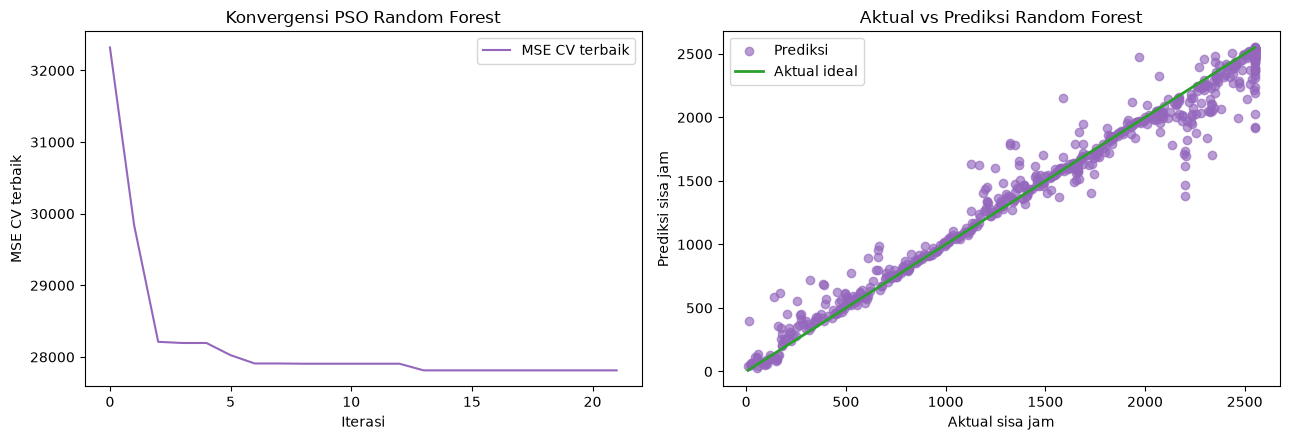

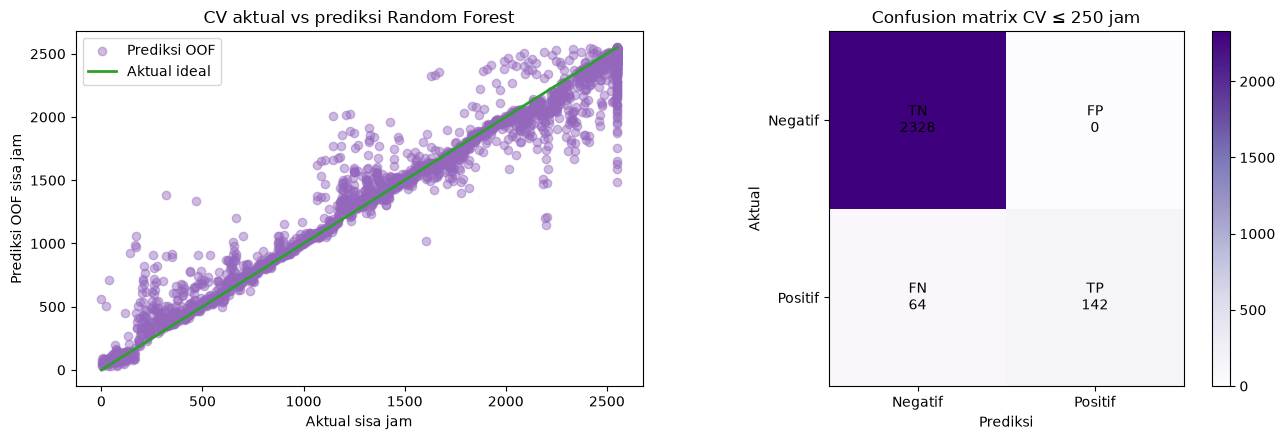

{'optimizer': 'PSO',
 'model': 'Random Forest',
 'data_scope': 'combined_pseudo_rul',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hours': {'unit_231': 54306.25769279888,
  'pt_amanah': 78637.0,
  'unit_230': 55006.6426331452,
  'unit_228': 55628.49338681787},
 'reference_model': 'newcode/scenarios/01_RF_SVR_data_single/models/best_model.joblib',
 'best_params': {'n_estimators': 201,
  'max_depth': 16,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 0.5788554465254323},
 'cv_mse': 27813.52443116817,
 'cv_rmse': 166.7738721477923,
 'test_mse': 20081.78958073203,
 'test_rmse': 141.71023103760726,
 'test_mae': 80.94527316348402,
 'test_r2': 0.9678050412782392,

In [5]:
print("=== Mulai optimasi PSO Random Forest ===", flush=True)
rf_start = time.perf_counter()
rf_obj = make_objective("rf")
rf_pos, rf_score, rf_history, rf_evals = run_pso(
    rf_obj, RF_BOUNDS, cfg["swarm_size"], cfg["iterations"],
    cfg["patience"], cfg["inertia"], cfg["cognitive"], cfg["social"],
    SEED, "Random Forest"
)
rf_result = evaluate(
    "rf", decode_rf(rf_pos), rf_score, rf_history,
    time.perf_counter() - rf_start, rf_evals
)
rf_result

## Optimasi SVR

=== Mulai optimasi PSO SVR ===
[SVR] Inisialisasi selesai | MSE CV terbaik: 43615.309431
[SVR] Iterasi 1/30 | MSE CV terbaik: 42312.588553 | Waktu: 47.3 detik
[SVR] Iterasi 2/30 | MSE CV terbaik: 42246.549378 | Waktu: 78.5 detik
[SVR] Iterasi 3/30 | MSE CV terbaik: 42246.273285 | Waktu: 117.1 detik
[SVR] Iterasi 4/30 | MSE CV terbaik: 42246.273285 | Waktu: 153.9 detik
[SVR] Iterasi 5/30 | MSE CV terbaik: 42243.699052 | Waktu: 192.5 detik
[SVR] Iterasi 6/30 | MSE CV terbaik: 42243.699052 | Waktu: 232.9 detik
[SVR] Iterasi 7/30 | MSE CV terbaik: 42243.683809 | Waktu: 271.6 detik
[SVR] Iterasi 8/30 | MSE CV terbaik: 42243.683809 | Waktu: 310.1 detik
[SVR] Iterasi 9/30 | MSE CV terbaik: 42243.683809 | Waktu: 347.4 detik
[SVR] Iterasi 10/30 | MSE CV terbaik: 42243.683809 | Waktu: 385.4 detik
[SVR] Iterasi 11/30 | MSE CV terbaik: 42243.683809 | Waktu: 424.9 detik
[SVR] Iterasi 12/30 | MSE CV terbaik: 42243.683809 | Waktu: 468.1 detik
[SVR] Iterasi 13/30 | MSE CV terbaik: 42243.683809 | Waktu

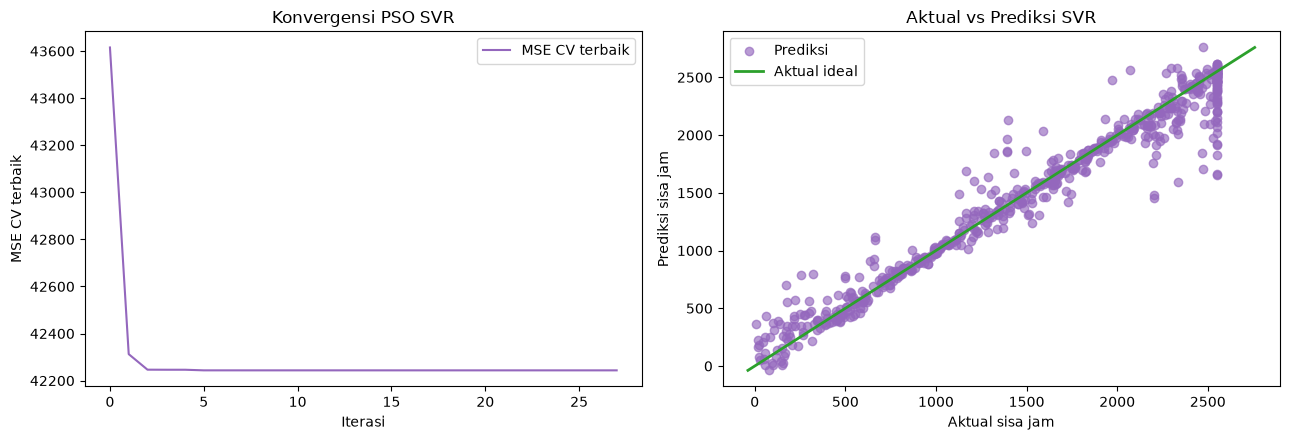

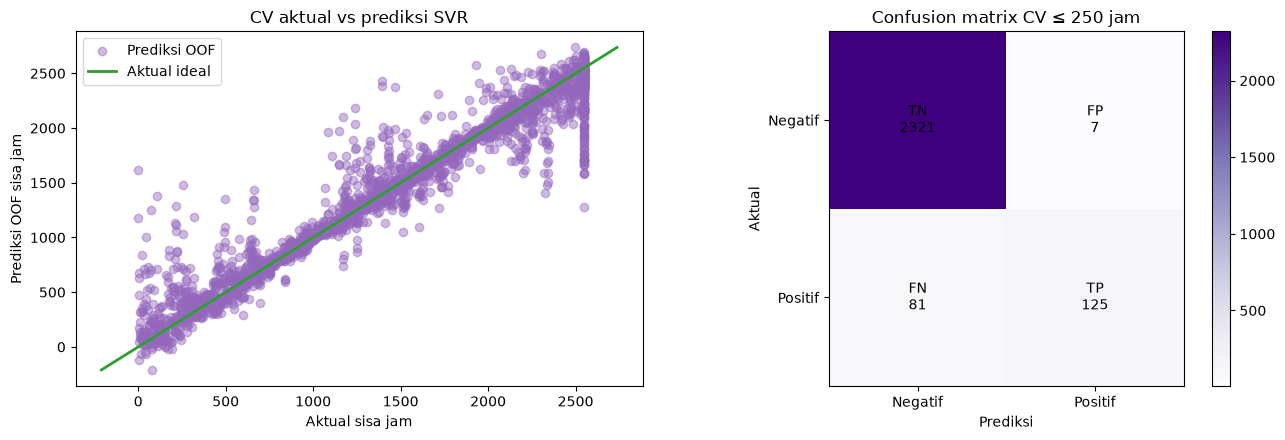

{'optimizer': 'PSO',
 'model': 'SVR',
 'data_scope': 'combined_pseudo_rul',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hours': {'unit_231': 54306.25769279888,
  'pt_amanah': 78637.0,
  'unit_230': 55006.6426331452,
  'unit_228': 55628.49338681787},
 'reference_model': 'newcode/scenarios/01_RF_SVR_data_single/models/best_model.joblib',
 'best_params': {'C': 1000.0,
  'epsilon': 14.569297389474531,
  'gamma': 1.0,
  'kernel': 'rbf'},
 'cv_mse': 42243.676723453194,
 'cv_rmse': 205.5326658306489,
 'test_mse': 29099.96743348215,
 'test_rmse': 170.5871256381388,
 'test_mae': 100.31779219595884,
 'test_r2': 0.9533471732407531,
 'cv_oof_metrics': {'mse': 42246.969928734325,
  'rmse':

In [6]:
print("=== Mulai optimasi PSO SVR ===", flush=True)
svr_start = time.perf_counter()
svr_obj = make_objective("svr")
svr_pos, svr_score, svr_history, svr_evals = run_pso(
    svr_obj, SVR_BOUNDS, cfg["swarm_size"], cfg["iterations"],
    cfg["patience"], cfg["inertia"], cfg["cognitive"], cfg["social"],
    SEED + 1, "SVR"
)
svr_result = evaluate(
    "svr", decode_svr(svr_pos), svr_score, svr_history,
    time.perf_counter() - svr_start, svr_evals
)
svr_result

## Perbandingan hasil yang tersedia

In [7]:
results = {}
for kind in ["rf", "svr"]:
    path = out_dir / f"pso_{kind}" / "metrics.json"
    if path.exists():
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("data_scope") == "combined_pseudo_rul" and item.get("feature_scope") == "sensor_only":
            results[kind] = item
if not results:
    raise FileNotFoundError("Belum ada hasil PSO data gabungan pseudo-RUL. Jalankan minimal salah satu cell optimasi.")
pd.DataFrame(results).T[["cv_rmse", "test_rmse", "test_mae", "test_r2", "objective_evaluations"]]

,cv_rmse,test_rmse,test_mae,test_r2,objective_evaluations
rf,166.773872,141.710231,80.945273,0.967805,440
svr,205.532666,170.587126,100.317792,0.953347,549
